# Crop Type & Cropping Pattern Mapping
### Multi-season Sentinel-2 images + Random Forest in Central Punjab Rice-Wheat Belt

This notebook builds a crop classification and cropping-pattern map using Google Earth Engine and scikit-learn. It combines Sentinel-2 imagery from the Kharif (monsoon) and Rabi (winter) seasons into a multi-temporal feature stack. A Random Forest classifier is then trained using manually verified training polygons to produce a four-class land cover map (rice, wheat, fallow, and water). Finally, the seasonal classifications are combined to generate a five-class cropping-pattern map that identifies single and double cropped agricultural land.

## 1. Setup
Authenticate and initialize the Earth Engine API.

In [38]:
import ee
ee.Authenticate()
ee.Initialize(project='future-graph-436510-d7')
print("GEE initialized")

GEE initialized


## 2. Study Area (AOI)
Defines the Area of Interest, a rectangular box over the central Punjab rice-wheat belt. This was narrowed down from an initial AOI covering the whole state, since that original extent spanned multiple agro-climatic zones (Himalayan foothills, semi-arid cotton belt) that a small training set couldn't adequately represent.

In [39]:
aoi = ee.Geometry.Rectangle([75.0, 30.2, 76.3, 31.0])
print("AOI defined")

print(aoi.getInfo())
print("Approx area (in km2): ", aoi.area().divide(1e6).getInfo())

AOI defined
{'type': 'Polygon', 'coordinates': [[[75, 30.2], [76.3, 30.2], [76.3, 31], [75, 31], [75, 30.2]]]}
Approx area (in km2):  11068.222776975254


## 3. Preprocessing: Cloud Masking
Builds cloud-free median composites for both crop seasons.

- **Cloud mask** uses the Scene Classification Layer (SCL) band, not QA60 — QA60 was not populated by ESA for most of this study's date range (Jan 2022–Feb 2024), so it silently passed clouds through.
- **Kharif** (Jun–Oct): monsoon-sown season, rice-dominant.
- **Rabi** (Nov–Mar): winter-sown season, wheat-dominant.

In [40]:
def mask_s2_clouds(image):
    scl = image.select('SCL')
    good_pixels = scl.eq(4).Or(scl.eq(5)).Or(scl.eq(6)).Or(scl.eq(7))
    return image.updateMask(good_pixels).divide(10000)

In [41]:
s2_kharif = (
    ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
    .filterBounds(aoi)
    .filterDate('2023-06-01', '2023-10-31')
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20))
    .map(mask_s2_clouds)
    .median()
    .clip(aoi)
)
print("Kharif loaded")

s2_rabi = (
    ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
    .filterBounds(aoi)
    .filterDate('2023-11-01', '2024-03-31')
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20))
    .map(mask_s2_clouds)
    .median()
    .clip(aoi)
)
print("Rabi loaded")

Kharif loaded
Rabi loaded


## 4. Feature Engineering
Derived NDVI (vegetation) and MNDWI (water) for each season, then combined all raw bands and indices from both seasons into one 16-band feature image. MNDWI was added specifically to separate flooded rice paddies from open water because plain NDVI alone confuses the two during early Kharif season.

In [44]:
ndvi_kharif = s2_kharif.normalizedDifference(['B8', 'B4']).rename('NDVI_kharif')
ndvi_rabi = s2_rabi.normalizedDifference(['B8', 'B4']).rename('NDVI_rabi')

print("NDVI Kharif: ", ndvi_kharif.reduceRegion(
    reducer=ee.Reducer.minMax(),
    geometry=aoi,
    scale=500,
).getInfo())

print("NDVI Rabi: ", ndvi_rabi.reduceRegion(
    reducer=ee.Reducer.minMax(),
    geometry=aoi,
    scale=500,
).getInfo())

NDVI Kharif:  {'NDVI_kharif_max': 0.852270247632992, 'NDVI_kharif_min': -0.21606649550110585}
NDVI Rabi:  {'NDVI_rabi_max': 0.8565315932993366, 'NDVI_rabi_min': -0.34663342456733215}


In [46]:
BANDS = ['B2', 'B3', 'B4', 'B8', 'B11', 'B12']

kharif_bands = s2_kharif.select(BANDS).rename([f'{b}_kharif' for b in BANDS])
rabi_bands   = s2_rabi.select(BANDS).rename([f'{b}_rabi'   for b in BANDS])

mndwi_kharif = s2_kharif.normalizedDifference(['B3', 'B11']).rename('MNDWI_kharif')
mndwi_rabi   = s2_rabi.normalizedDifference(['B3', 'B11']).rename('MNDWI_rabi')

feature_stack = kharif_bands.addBands(rabi_bands).addBands(ndvi_kharif).addBands(ndvi_rabi).addBands(mndwi_kharif).addBands(mndwi_rabi)

feature_names = [f'{b}_kharif' for b in BANDS] + [f'{b}_rabi'   for b in BANDS] + ['NDVI_kharif', 'NDVI_rabi', 'MNDWI_kharif', 'MNDWI_rabi']

print(f"Number of feature bands: {len(feature_names)}")
print(feature_names)

Number of feature bands: 16
['B2_kharif', 'B3_kharif', 'B4_kharif', 'B8_kharif', 'B11_kharif', 'B12_kharif', 'B2_rabi', 'B3_rabi', 'B4_rabi', 'B8_rabi', 'B11_rabi', 'B12_rabi', 'NDVI_kharif', 'NDVI_rabi', 'MNDWI_kharif', 'MNDWI_rabi']


## 5. Interactive Visualization
An interactive geemap viewer is used to visually identify and digitize training locations, cross-checking true-colour and NDVI layers across both the seasons.

- **Base map**: true-colour + NDVI layers for Kharif and Rabi.
- **Dynamic World** (Google global land-cover model) overlaid as a guide to locate candidate Water/Bare/Crop pixels. This came very handy for rare classes like fallow which was hard to spot by eye in this intensively farmed region.
- **clear_drawings()** is an helper function that I used to reset the polygon list between classes when collecting training polygons.

In [47]:
import geemap

Map = geemap.Map(center=[30.9, 75.0], zoom=8)

vis_rgb_kharif = {'min': 0, 'max': 0.3, 'bands': ['B4_kharif', 'B3_kharif', 'B2_kharif']}
vis_rgb_rabi = {'min': 0, 'max': 0.3, 'bands': ['B4_rabi', 'B3_rabi', 'B2_rabi']}

vis_ndvi = {'min': -0.1, 'max': 0.9, 'palette': ['white', 'yellow', 'darkgreen']}

Map.addLayer(feature_stack, vis_rgb_kharif, 'Kharif RGB')
Map.addLayer(feature_stack, vis_rgb_rabi, 'Rabi RGB')
Map.addLayer(ndvi_kharif, vis_ndvi, 'NDVI Kharif')
Map.addLayer(ndvi_rabi, vis_ndvi, 'NDVI Rabi')
Map.addLayer(aoi, {'color': 'red'}, 'AOI')

Map

Map(center=[30.9, 75.0], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', …

In [48]:
dw = ee.ImageCollection('GOOGLE/DYNAMICWORLD/V1').filterBounds(aoi).filterDate('2023-06-01', '2023-10-31').select('label')

dw_mode = dw.mode().clip(aoi)

Map.addLayer(dw_mode, {'min': 0, 'max': 8,  'palette': ['419bdf','397d49','88b053','7a87c6','e49635','dfc35a','c4281b','a59b8f','b39fe1']}, 
             'Dynamic World land cover')

In [49]:
def clear_drawings():
    Map._draw_control.geometries = []
    Map._draw_control.properties = []
    print("Cleared. Draw features now:", len(Map.draw_features))

## 6. Training Data: Hand Verified Polygons per Class
Training polygons for Rice, Wheat, Fallow, and Water, written interactively by cross-checking both the seasons images one after the other and seeing the changes. Each polygon carries a poly_id which is required later to prevent pixels from the same polygon leaking between train and test sets.

In [50]:
# 0 = Rice, 1 = Wheat, 2 = Fallow/Barren, 3 = Water

rice = ee.FeatureCollection([
    ee.Feature(ee.Geometry.Polygon([[[75.18587, 30.292217], [75.185848, 30.291754], [75.189078, 30.291763], [75.189067, 30.292245], [75.18587, 30.292217]]]), {'class': 0, 'poly_id': 'rice_0'}),
    ee.Feature(ee.Geometry.Polygon([[[75.199496, 30.303579], [75.199496, 30.302754], [75.198262, 30.302745], [75.197875, 30.303616], [75.199496, 30.303579]]]), {'class': 0, 'poly_id': 'rice_1'}),
    ee.Feature(ee.Geometry.Polygon([[[75.061651, 30.297808], [75.06163, 30.295974], [75.062145, 30.296057], [75.062156, 30.297789], [75.061651, 30.297808]]]), {'class': 0, 'poly_id': 'rice_2'}),
    ee.Feature(ee.Geometry.Polygon([[[75.055997, 30.306302], [75.055987, 30.304273], [75.057296, 30.304273], [75.057274, 30.305654], [75.055997, 30.306302]]]), {'class': 0, 'poly_id': 'rice_3'}),
    ee.Feature(ee.Geometry.Polygon([[[75.097175, 30.300469], [75.097153, 30.296819], [75.097668, 30.297004], [75.097711, 30.298023], [75.098569, 30.29806], [75.098634, 30.297227], [75.099106, 30.297227], [75.09902, 30.29919], [75.099664, 30.299209], [75.099642, 30.300209], [75.101123, 30.300765], [75.100651, 30.301432], [75.098655, 30.300728], [75.098591, 30.300339], [75.097647, 30.300302], [75.097625, 30.300691], [75.097175, 30.300469]]]), {'class': 0, 'poly_id': 'rice_4'}),
])

wheat = ee.FeatureCollection([
    ee.Feature(ee.Geometry.Polygon([[[75.490279, 30.607163], [75.490215, 30.606387], [75.491803, 30.606277], [75.491824, 30.607145], [75.490279, 30.607163]]]), {'class': 1, 'poly_id': 'wheat_0'}),
    ee.Feature(ee.Geometry.Polygon([[[75.61969, 30.639495], [75.619626, 30.637538], [75.621622, 30.637502], [75.620999, 30.639311], [75.620635, 30.639274], [75.620699, 30.639939], [75.61969, 30.639495]]]), {'class': 1, 'poly_id': 'wheat_1'}),
    ee.Feature(ee.Geometry.Polygon([[[75.60261, 30.606223], [75.602567, 30.604626], [75.604026, 30.604617], [75.604026, 30.605697], [75.60261, 30.606223]]]), {'class': 1, 'poly_id': 'wheat_2'}),
    ee.Feature(ee.Geometry.Polygon([[[75.798765, 30.614912], [75.798776, 30.614321], [75.800085, 30.614321], [75.800085, 30.614829], [75.798765, 30.614912]]]), {'class': 1, 'poly_id': 'wheat_3'}),
    ee.Feature(ee.Geometry.Polygon([[[75.74039, 30.677206], [75.74039, 30.676818], [75.73981, 30.676726], [75.739875, 30.675711], [75.739059, 30.675656], [75.739059, 30.675213], [75.73951, 30.675157], [75.739446, 30.674253], [75.738845, 30.674272], [75.738823, 30.673921], [75.739231, 30.673902], [75.739188, 30.671411], [75.741098, 30.671411], [75.741012, 30.677114], [75.74039, 30.677206]]]), {'class': 1, 'poly_id': 'wheat_4'}),
])

fallow = ee.FeatureCollection([
    ee.Feature(ee.Geometry.Polygon([[[75.303812, 30.383999], [75.303801, 30.383582], [75.303329, 30.383619], [75.303415, 30.383332], [75.303919, 30.38324], [75.303844, 30.382869], [75.304552, 30.382851], [75.304542, 30.38386], [75.303812, 30.383999]]]), {'class': 2, 'poly_id': 'fallow_0'}),
    ee.Feature(ee.Geometry.Polygon([[[75.036696, 30.229934], [75.036685, 30.22897], [75.036932, 30.228915], [75.036932, 30.228525], [75.037565, 30.228497], [75.037748, 30.228386], [75.038617, 30.228331], [75.038499, 30.229118], [75.038177, 30.22936], [75.038209, 30.229934], [75.036696, 30.229934]]]), {'class': 2, 'poly_id': 'fallow_1'}),
    ee.Feature(ee.Geometry.Polygon([[[75.066458, 30.21906], [75.066361, 30.217521], [75.066018, 30.217484], [75.066029, 30.216436], [75.068346, 30.216446], [75.068357, 30.216798], [75.06958, 30.216715], [75.069505, 30.217373], [75.068443, 30.217354], [75.068389, 30.219014], [75.066458, 30.21906]]]), {'class': 2, 'poly_id': 'fallow_2'}),
    ee.Feature(ee.Geometry.Polygon([[[75.081028, 30.238685], [75.080609, 30.23823], [75.081629, 30.237572], [75.082262, 30.238064], [75.081028, 30.238685]]]), {'class': 2, 'poly_id': 'fallow_3'}),
])

water = ee.FeatureCollection([
    ee.Feature(ee.Geometry.Polygon([[[75.488069, 30.740633], [75.487629, 30.740146], [75.487533, 30.739482], [75.487511, 30.739122], [75.488423, 30.739943], [75.488595, 30.741013], [75.488927, 30.741585], [75.488327, 30.741234], [75.488069, 30.740633]]]), {'class': 3, 'poly_id': 'water_0'}),
    ee.Feature(ee.Geometry.Polygon([[[75.377052, 30.786045], [75.377052, 30.786206], [75.377836, 30.786206], [75.377836, 30.786045], [75.377052, 30.786045]]]), {'class': 3, 'poly_id': 'water_1'}),
    ee.Feature(ee.Geometry.Polygon([[[75.337962, 30.818265], [75.336385, 30.817224], [75.335484, 30.816165], [75.335462, 30.815851], [75.33587, 30.81587], [75.336986, 30.816994], [75.337501, 30.817022], [75.338187, 30.817648], [75.338241, 30.818054], [75.337962, 30.818265]]]), {'class': 3, 'poly_id': 'water_2'}),
    ee.Feature(ee.Geometry.Polygon([[[75.334947, 30.848141], [75.333788, 30.846907], [75.334185, 30.846548], [75.335226, 30.846548], [75.335805, 30.846041], [75.336331, 30.846944], [75.336117, 30.847635], [75.334947, 30.848141]]]), {'class': 3, 'poly_id': 'water_3'}),
    ee.Feature(ee.Geometry.Polygon([[[75.370481, 30.996773], [75.371017, 30.99554], [75.370867, 30.994565], [75.370545, 30.993591], [75.371034, 30.992991], [75.371361, 30.993185], [75.370991, 30.993626], [75.371001, 30.994159], [75.371093, 30.994684], [75.371173, 30.99513], [75.371366, 30.995672], [75.37172, 30.995737], [75.371683, 30.996523], [75.371248, 30.996987], [75.370481, 30.996773]]]), {'class': 3, 'poly_id': 'water_4'}),
])

training_fc = rice.merge(wheat).merge(fallow).merge(water)

print(f"Number of polygons: {training_fc.size().getInfo()}")
print("Classes: 0=Rice, 1=Wheat, 2=Fallow, 3=Water")

Number of polygons: 19
Classes: 0=Rice, 1=Wheat, 2=Fallow, 3=Water


## 7. Sample Extraction & Class Balancing
Extracts pixel values from inside each training polygon sampleRegions, then caps each class at a fixed sample count which (a) makes sure that we stay under Earth Engine's 5,000-element limit and (b) guarantees balanced classes regardless of different sized polygons that we have

In [52]:
training_samples = feature_stack.sampleRegions(
    collection=training_fc,
    properties=['class', 'poly_id'],
    scale=10,        # resolution of sentinel-2 satellite images
    tileScale=4      # to avoid memory errors
)

def cap_class(samples, class_id, n):
    return samples.filter(ee.Filter.eq('class', class_id)).randomColumn('rand').sort('rand').limit(n)

N_PER_CLASS = 400

training_samples_capped = ee.FeatureCollection([
    cap_class(training_samples, 0, N_PER_CLASS),  # Rice
    cap_class(training_samples, 1, N_PER_CLASS),  # Wheat
    cap_class(training_samples, 2, N_PER_CLASS),  # Fallow
    cap_class(training_samples, 3, N_PER_CLASS),  # Water
]).flatten()

# Converting to pandas dataframe
import pandas as pd

training_dict = training_samples_capped.getInfo()
rows = [feat['properties'] for feat in training_dict['features']]
df = pd.DataFrame(rows)

print(f"Number of samples: {len(df)}")
print(f"Columns: {list(df.columns)}")
df.head()

Number of samples: 1600
Columns: ['B11_kharif', 'B11_rabi', 'B12_kharif', 'B12_rabi', 'B2_kharif', 'B2_rabi', 'B3_kharif', 'B3_rabi', 'B4_kharif', 'B4_rabi', 'B8_kharif', 'B8_rabi', 'MNDWI_kharif', 'MNDWI_rabi', 'NDVI_kharif', 'NDVI_rabi', 'class', 'poly_id', 'rand']


,B11_kharif,B11_rabi,B12_kharif,B12_rabi,B2_kharif,B2_rabi,B3_kharif,B3_rabi,B4_kharif,B4_rabi,B8_kharif,B8_rabi,MNDWI_kharif,MNDWI_rabi,NDVI_kharif,NDVI_rabi,class,poly_id,rand
0,0.17720,0.15590,0.08975,0.0805,0.01980,0.0615,0.07120,0.0786,0.03925,0.07490,0.42700,0.3002,-0.426731,-0.329638,0.831635,0.600640,0,rice_4,0.000823
1,0.17800,0.16350,0.09130,0.1301,0.01770,0.0612,0.05945,0.0874,0.03315,0.10480,0.38220,0.2946,-0.499263,-0.303308,0.840376,0.475213,0,rice_4,0.000876
2,0.16420,0.13690,0.08420,0.0985,0.01500,0.0672,0.06300,0.0856,0.03425,0.09660,0.40225,0.2940,-0.445423,-0.230562,0.843070,0.505376,0,rice_4,0.000893
3,0.15925,0.14550,0.08515,0.0934,0.02670,0.0334,0.06475,0.0458,0.05085,0.04420,0.32090,0.1936,-0.421875,-0.521171,0.726429,0.628259,0,rice_4,0.001462
4,0.17690,0.14125,0.08805,0.0994,0.01915,0.0412,0.05490,0.0607,0.03185,0.04475,0.39210,0.3270,-0.526316,-0.398861,0.849746,0.759247,0,rice_0,0.003425


In [53]:
feature_names = [col for col in df.columns if col not in ('class', 'rand', 'poly_id')]
print("Feature order confirmed:")
print(feature_names)

Feature order confirmed:
['B11_kharif', 'B11_rabi', 'B12_kharif', 'B12_rabi', 'B2_kharif', 'B2_rabi', 'B3_kharif', 'B3_rabi', 'B4_kharif', 'B4_rabi', 'B8_kharif', 'B8_rabi', 'MNDWI_kharif', 'MNDWI_rabi', 'NDVI_kharif', 'NDVI_rabi']


In [54]:
print(df['class'].value_counts().sort_index())

class
0    400
1    400
2    400
3    400
Name: count, dtype: int64


## 8. Model Training: Random Forest (scikit-learn)
Trains a Random Forest on the extracted samples.

**Important:** the train/test split is grouped by poly_id (GroupShuffleSplit), not a plain random split. I tried a pixel by pizel random split first but it produced a fake 99.8% accuracy. Pixels from the same polygon are nearly identical, so a random split let the model test on near-duplicates of its own training data. Grouping by polygon fixed the leak.

In [55]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupShuffleSplit

X = df[feature_names].values
y = df['class'].values.astype(int)
groups = df['poly_id'].values

gss = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=42)
train_ids, test_ids = next(gss.split(X, y, groups=groups))

X_train, X_test = X[train_ids], X[test_ids]
y_train, y_test = y[train_ids], y[test_ids]

rf = RandomForestClassifier(
    n_estimators=100,   
    max_depth=10,       
    random_state=42,
    n_jobs=-1 # to use all cpu cores. mine has 12 cores and 16 threads ;) 
)
rf.fit(X_train, y_train)

print(f"Training samples : {len(X_train)} ({len(set(groups[train_ids]))} polygons)")
print(f"Testing samples : {len(X_test)} ({len(set(groups[test_ids]))} polygons)")
print("Random Forest trained successfully")

Training samples : 1070 (13 polygons)
Testing samples : 530 (6 polygons)
Random Forest trained successfully


## 9. Accuracy Assessment
Confusion matrix, overall accuracy, and kappa coefficient on the test set, this should be the honest accuracy figure for this model.

ACCURACY ASSESSMENT
Overall Accuracy : 95.28%
Kappa Coefficient: 0.9300

Per Class Report:
              precision    recall  f1-score   support

        Rice       1.00      0.90      0.95       262
       Wheat       0.96      1.00      0.98        45
      Fallow       1.00      1.00      1.00       126
       Water       0.81      1.00      0.89        97

    accuracy                           0.95       530
   macro avg       0.94      0.98      0.96       530
weighted avg       0.96      0.95      0.95       530



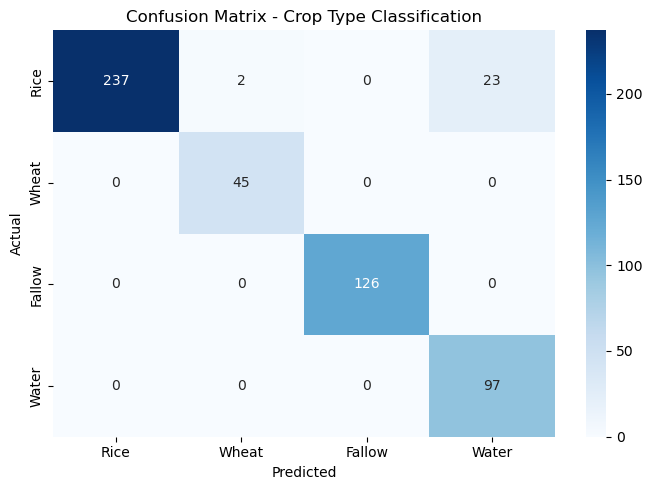

In [58]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, cohen_kappa_score
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = rf.predict(X_test)

oa = accuracy_score(y_test, y_pred)
kap = cohen_kappa_score(y_test, y_pred)

print("ACCURACY ASSESSMENT")
print(f"Overall Accuracy : {oa*100:.2f}%")
print(f"Kappa Coefficient: {kap:.4f}")
print("\nPer Class Report:")
print(classification_report(y_test, y_pred,target_names=['Rice', 'Wheat', 'Fallow', 'Water']))

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Rice','Wheat','Fallow','Water'], 
            yticklabels=['Rice','Wheat','Fallow','Water'],
            ax=ax)

ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix - Crop Type Classification')
plt.tight_layout()
plt.show()

## 10. Complete AOI Classification (Earth Engine)
Trained Earth Engine's own Random Forest (smileRandomForest) on the same samples and classified the full feature stack, producing a crop-type map covering the entire AOI.

In [60]:
gee_classifier = ee.Classifier.smileRandomForest(numberOfTrees=100).train(
    features=training_samples_capped, classProperty='class', inputProperties=feature_names)

crop_map = feature_stack.classify(gee_classifier)

print("Classification is done")

Classification is done


## 11. Classification Map Visualization

In [61]:
import geemap

vis_classified = {
    'min': 0, 'max': 3,
    'palette': [
        '#2ecc71', # 0 - Rice (green)
        '#3498db', # 1 - Wheat (blue)
        '#95a5a6', # 2 - Fallow (grey)
        '#1a6fa8', # 3 - Water (dark blue)
    ]
}

Map2 = geemap.Map(center=[30.9, 75.0], zoom=8)
Map2.addLayer(crop_map, vis_classified, 'Crop Classification')
Map2.addLayer(aoi, {'color': 'red'}, 'AOI')

legend_dict = {
    'Rice': '#2ecc71',
    'Wheat': '#3498db',
    'Fallow/Barren': '#95a5a6',
    'Water': '#1a6fa8',
}
Map2.add_legend(title='Crop Types', legend_dict=legend_dict)

Map2

Map(center=[30.9, 75.0], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', …

## 12. Cropland Masking (Dynamic World)
Builds a cropland mask from Dynamic World, flagging a pixel as cropland if it was labelled "crops" in either of the two seasons. Using only one season would exclude fields that are only active in the other and flags as fallow which is incorrect. Applied to the classified map so area statistics only care about cropland.

In [62]:
dw_kharif_mode = (
    ee.ImageCollection('GOOGLE/DYNAMICWORLD/V1')
    .filterBounds(aoi)
    .filterDate('2023-06-01', '2023-10-31')
    .select('label')
    .mode()
    .clip(aoi)
)

dw_rabi_mode = (
    ee.ImageCollection('GOOGLE/DYNAMICWORLD/V1')
    .filterBounds(aoi)
    .filterDate('2023-11-01', '2024-03-31')
    .select('label')
    .mode()
    .clip(aoi)
)

cropland_mask = dw_kharif_mode.eq(4).Or(dw_rabi_mode.eq(4))

crop_map_masked = crop_map.updateMask(cropland_mask)
Map2.addLayer(crop_map_masked, vis_classified, 'Crop Classification (cropland only)')

## 13. Feature Importance: MDI vs Permutation
Two different importance measures, compared deliberately:

- **Mean Decrease in Impurity (MDI)** - this is fast but is biased when features are correlated (e.g. MNDWI is derived from bands B3/B11, which are also present as raw features, so credit gets split between them).
- **Permutation importance** - this adctually measures the drop in accuracy when a feature is shuffled which makes it more reliable for confirming whether a feature genuinely matters and so used here to confirm MNDWI's real contribution in separating rice from water.

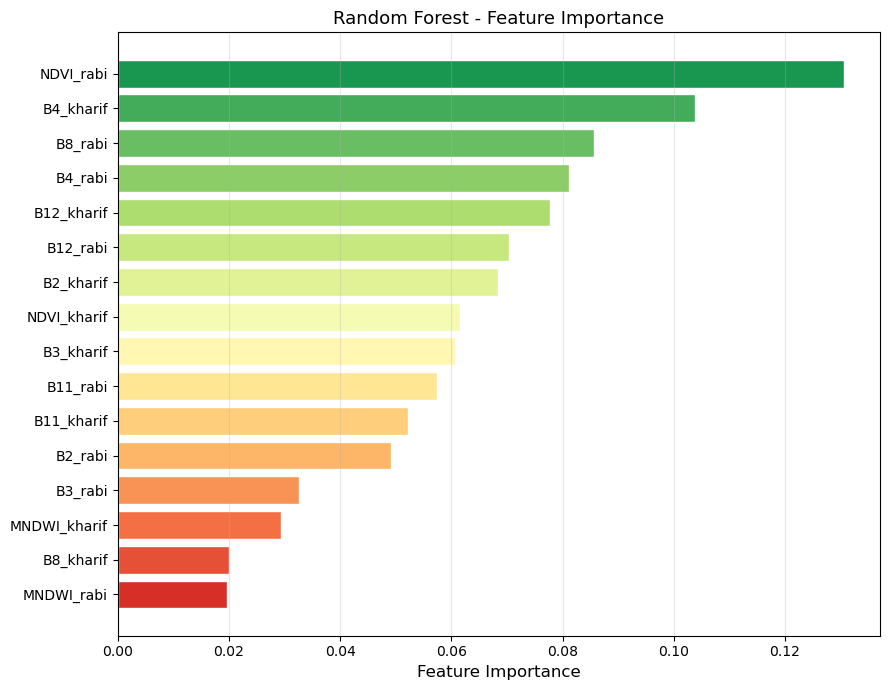

In [64]:
import matplotlib.pyplot as plt
import numpy as np

importances = rf.feature_importances_
feat_df = pd.DataFrame({'Feature': feature_names,'Importance': importances}).sort_values('Importance', ascending=True)
fig, ax = plt.subplots(figsize=(9, 7))
colors = plt.cm.RdYlGn(np.linspace(0.1, 0.9, len(feature_names)))
ax.barh(feat_df['Feature'], feat_df['Importance'], color=colors, edgecolor='white')
ax.set_xlabel('Feature Importance', fontsize=12)
ax.set_title('Random Forest - Feature Importance', fontsize=13)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

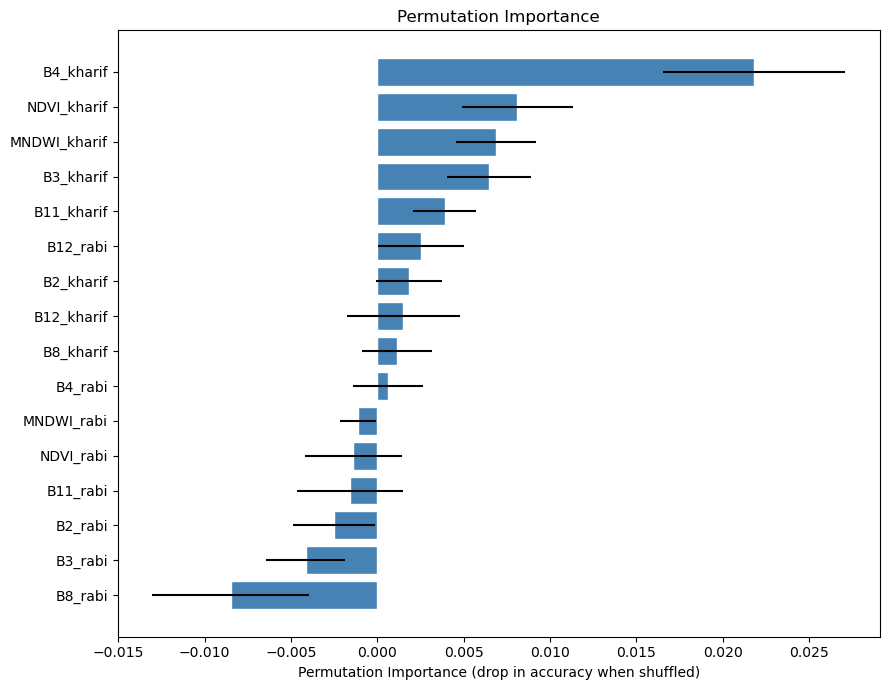

In [65]:
from sklearn.inspection import permutation_importance

perm_result = permutation_importance(rf, X_test, y_test, n_repeats=30, random_state=42, n_jobs=-1)

perm_df = pd.DataFrame({'Feature': feature_names,'Importance': perm_result.importances_mean,'Std': perm_result.importances_std}).sort_values(
    'Importance', ascending=True)

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(perm_df['Feature'], perm_df['Importance'], xerr=perm_df['Std'], color='steelblue', edgecolor='white')
ax.set_xlabel('Permutation Importance (drop in accuracy when shuffled)') # Here drop in accuracy was a good thing because earlier it was 98.8% duhhh
ax.set_title('Permutation Importance')
plt.tight_layout()
plt.show()

## 14. Area Statistics for 4-Class Crop Map
Computed the area (in km2) of each class within the masked cropland.

Rice: 3062.33 km2
Wheat: 6187.85 km2
Fallow/Barren: 86.83 km2
Water: 312.13 km2


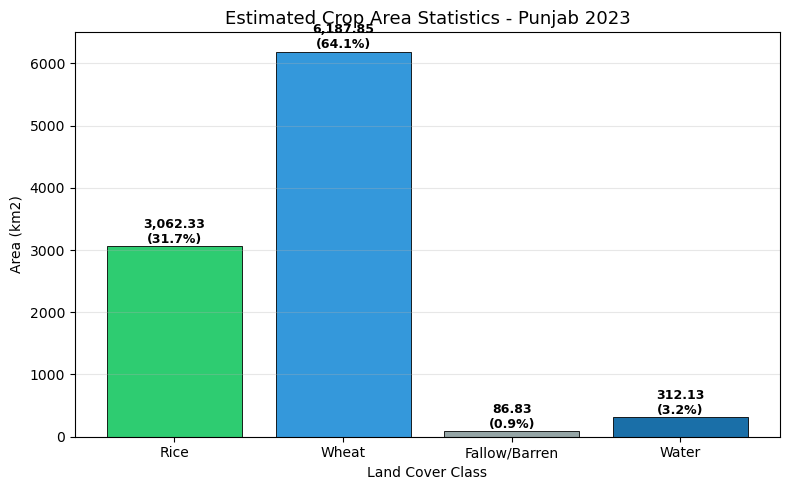

In [68]:
class_names = ['Rice', 'Wheat', 'Fallow/Barren', 'Water']
areas = {}

for i, name in enumerate(class_names):
    class_mask = crop_map_masked.eq(i)
    area = class_mask.multiply(ee.Image.pixelArea()).reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=aoi,
        scale=100,
        maxPixels=1e13
    ).getInfo()
    
    areas[name] = round(area['classification'] / 1e6, 2)
    print(f"{name}: {areas[name]} km2")

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#2ecc71', '#3498db', '#95a5a6', '#1a6fa8']
bars = ax.bar(areas.keys(), areas.values(), color=colors, edgecolor='black', linewidth=0.6)
ax.set_title('Estimated Crop Area Statistics - Punjab 2023', fontsize=13)
ax.set_xlabel('Land Cover Class')
ax.set_ylabel('Area (km2)')
ax.grid(axis='y', alpha=0.3)

total = sum(areas.values())
for bar, (k, v) in zip(bars, areas.items()):
    ax.text(bar.get_x()+bar.get_width()/2, v+50, 
            f'{v:,}\n({v/total*100:.1f}%)', 
            ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

## 15. Investigating Cropping Pattern
The 4-class area stats showed Wheat area at roughly double Rice area which was unexpected for a region known for intensive rice-wheat rotation, where most fields grow both crops. This checks whether "Wheat" and "Rice" pixels were also green in the other season, which would mean they are double-cropped.

In [72]:
wheat_pixels = crop_map_masked.eq(1)
wheat_that_was_also_kharif_green = wheat_pixels.And(ndvi_kharif.gt(0.5))

stats = wheat_that_was_also_kharif_green.multiply(ee.Image.pixelArea()).reduceRegion(
    reducer=ee.Reducer.sum(), geometry=aoi, scale=100, maxPixels=1e13
).getInfo()

print("Wheat-labeled area that was also green in Kharif :", round(stats['classification'] / 1e6, 2), "km2")

Wheat-labeled area that was also green in Kharif : 5214.69 km2


In [73]:
rice_pixels = crop_map_masked.eq(0)
rice_also_rabi_green = rice_pixels.And(ndvi_rabi.gt(0.5))

stats2 = rice_also_rabi_green.multiply(ee.Image.pixelArea()).reduceRegion(
    reducer=ee.Reducer.sum(), geometry=aoi, scale=100, maxPixels=1e13
).getInfo()

print("Rice-labeled area that was also green in Rabi :", round(stats2['classification'] / 1e6, 2), "km2")

Rice-labeled area that was also green in Rabi : 2508.72 km2


## 16. 5-Class Cropping Pattern Map
Roughly 77% of classified cropland turns out to be double-cropped rice-wheat rotation, explaining the earlier rice to wheat ratio imbalance.
So I built a map distinguishing Double-Cropped, Rice-only, Wheat-only land + fallow and water.

In [74]:
classifier_rice  = crop_map_masked.eq(0)
classifier_wheat = crop_map_masked.eq(1)

is_water  = crop_map_masked.eq(3)
is_fallow = crop_map_masked.eq(2)

is_double     = ndvi_kharif.gt(0.5).And(ndvi_rabi.gt(0.5))
is_rice_only  = ndvi_kharif.gt(0.5).And(ndvi_rabi.lte(0.5))
is_wheat_only = ndvi_kharif.lte(0.5).And(ndvi_rabi.gt(0.5))

cropping_pattern = (
    ee.Image(0)
    .where(classifier_rice, 2)      
    .where(classifier_wheat, 3)
    .where(is_double, 1)
    .where(is_rice_only, 2)
    .where(is_wheat_only, 3)
    .where(is_fallow, 4)
    .where(is_water, 5)
    .updateMask(cropland_mask)
    .rename('cropping_pattern')
)

In [75]:
vis_cropping = {'min': 1, 'max': 5, 'palette': ['9b59b6', '2ecc71', 'f1c40f', '95a5a6', '1a6fa8']}
vis_rgb = {'bands': ['B4', 'B3', 'B2'], 'min': 0, 'max': 0.3}

Map3 = geemap.Map(center=[30.6, 75.6], zoom=9)

Map3.addLayer(s2_kharif, vis_rgb, 'Kharif RGB', False)   
Map3.addLayer(s2_rabi, vis_rgb, 'Rabi RGB', False)

Map3.addLayer(cropping_pattern, vis_cropping, 'Cropping Pattern (5-class)')
Map3.addLayer(aoi, {'color': 'red'}, 'AOI')

legend_dict2 = {
    'Double-cropped (Rice+Wheat)': '#9b59b6',
    'Rice only': '#2ecc71',
    'Wheat only': '#f1c40f',
    'Fallow': '#95a5a6',
    'Water': '#1a6fa8',
}
Map3.add_legend(title="Cropping Pattern", legend_dict=legend_dict2)
Map3

Map(center=[30.6, 75.6], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', …

In [81]:
class_names_cp = {1: 'Double-cropped', 2: 'Rice-only', 3: 'Wheat-only', 4: 'Fallow', 5: 'Water'}
total_area = 0
for value, name in class_names_cp.items():
    mask = cropping_pattern.eq(value)
    area_img = mask.multiply(ee.Image.pixelArea())
    stat = area_img.reduceRegion(reducer=ee.Reducer.sum(), geometry=aoi, scale=100, maxPixels=1e13).getInfo()
    area_km2 = (stat.get('cropping_pattern')) / 1e6
    print(f"{name}: {area_km2:.2f} km2")
    total_area += area_km2

print(f"\nTotal: {total_area:.2f} km2")

Double-cropped: 7392.01 km2
Rice-only: 876.01 km2
Wheat-only: 974.66 km2
Fallow: 87.70 km2
Water: 318.76 km2

Total: 9649.14 km2
